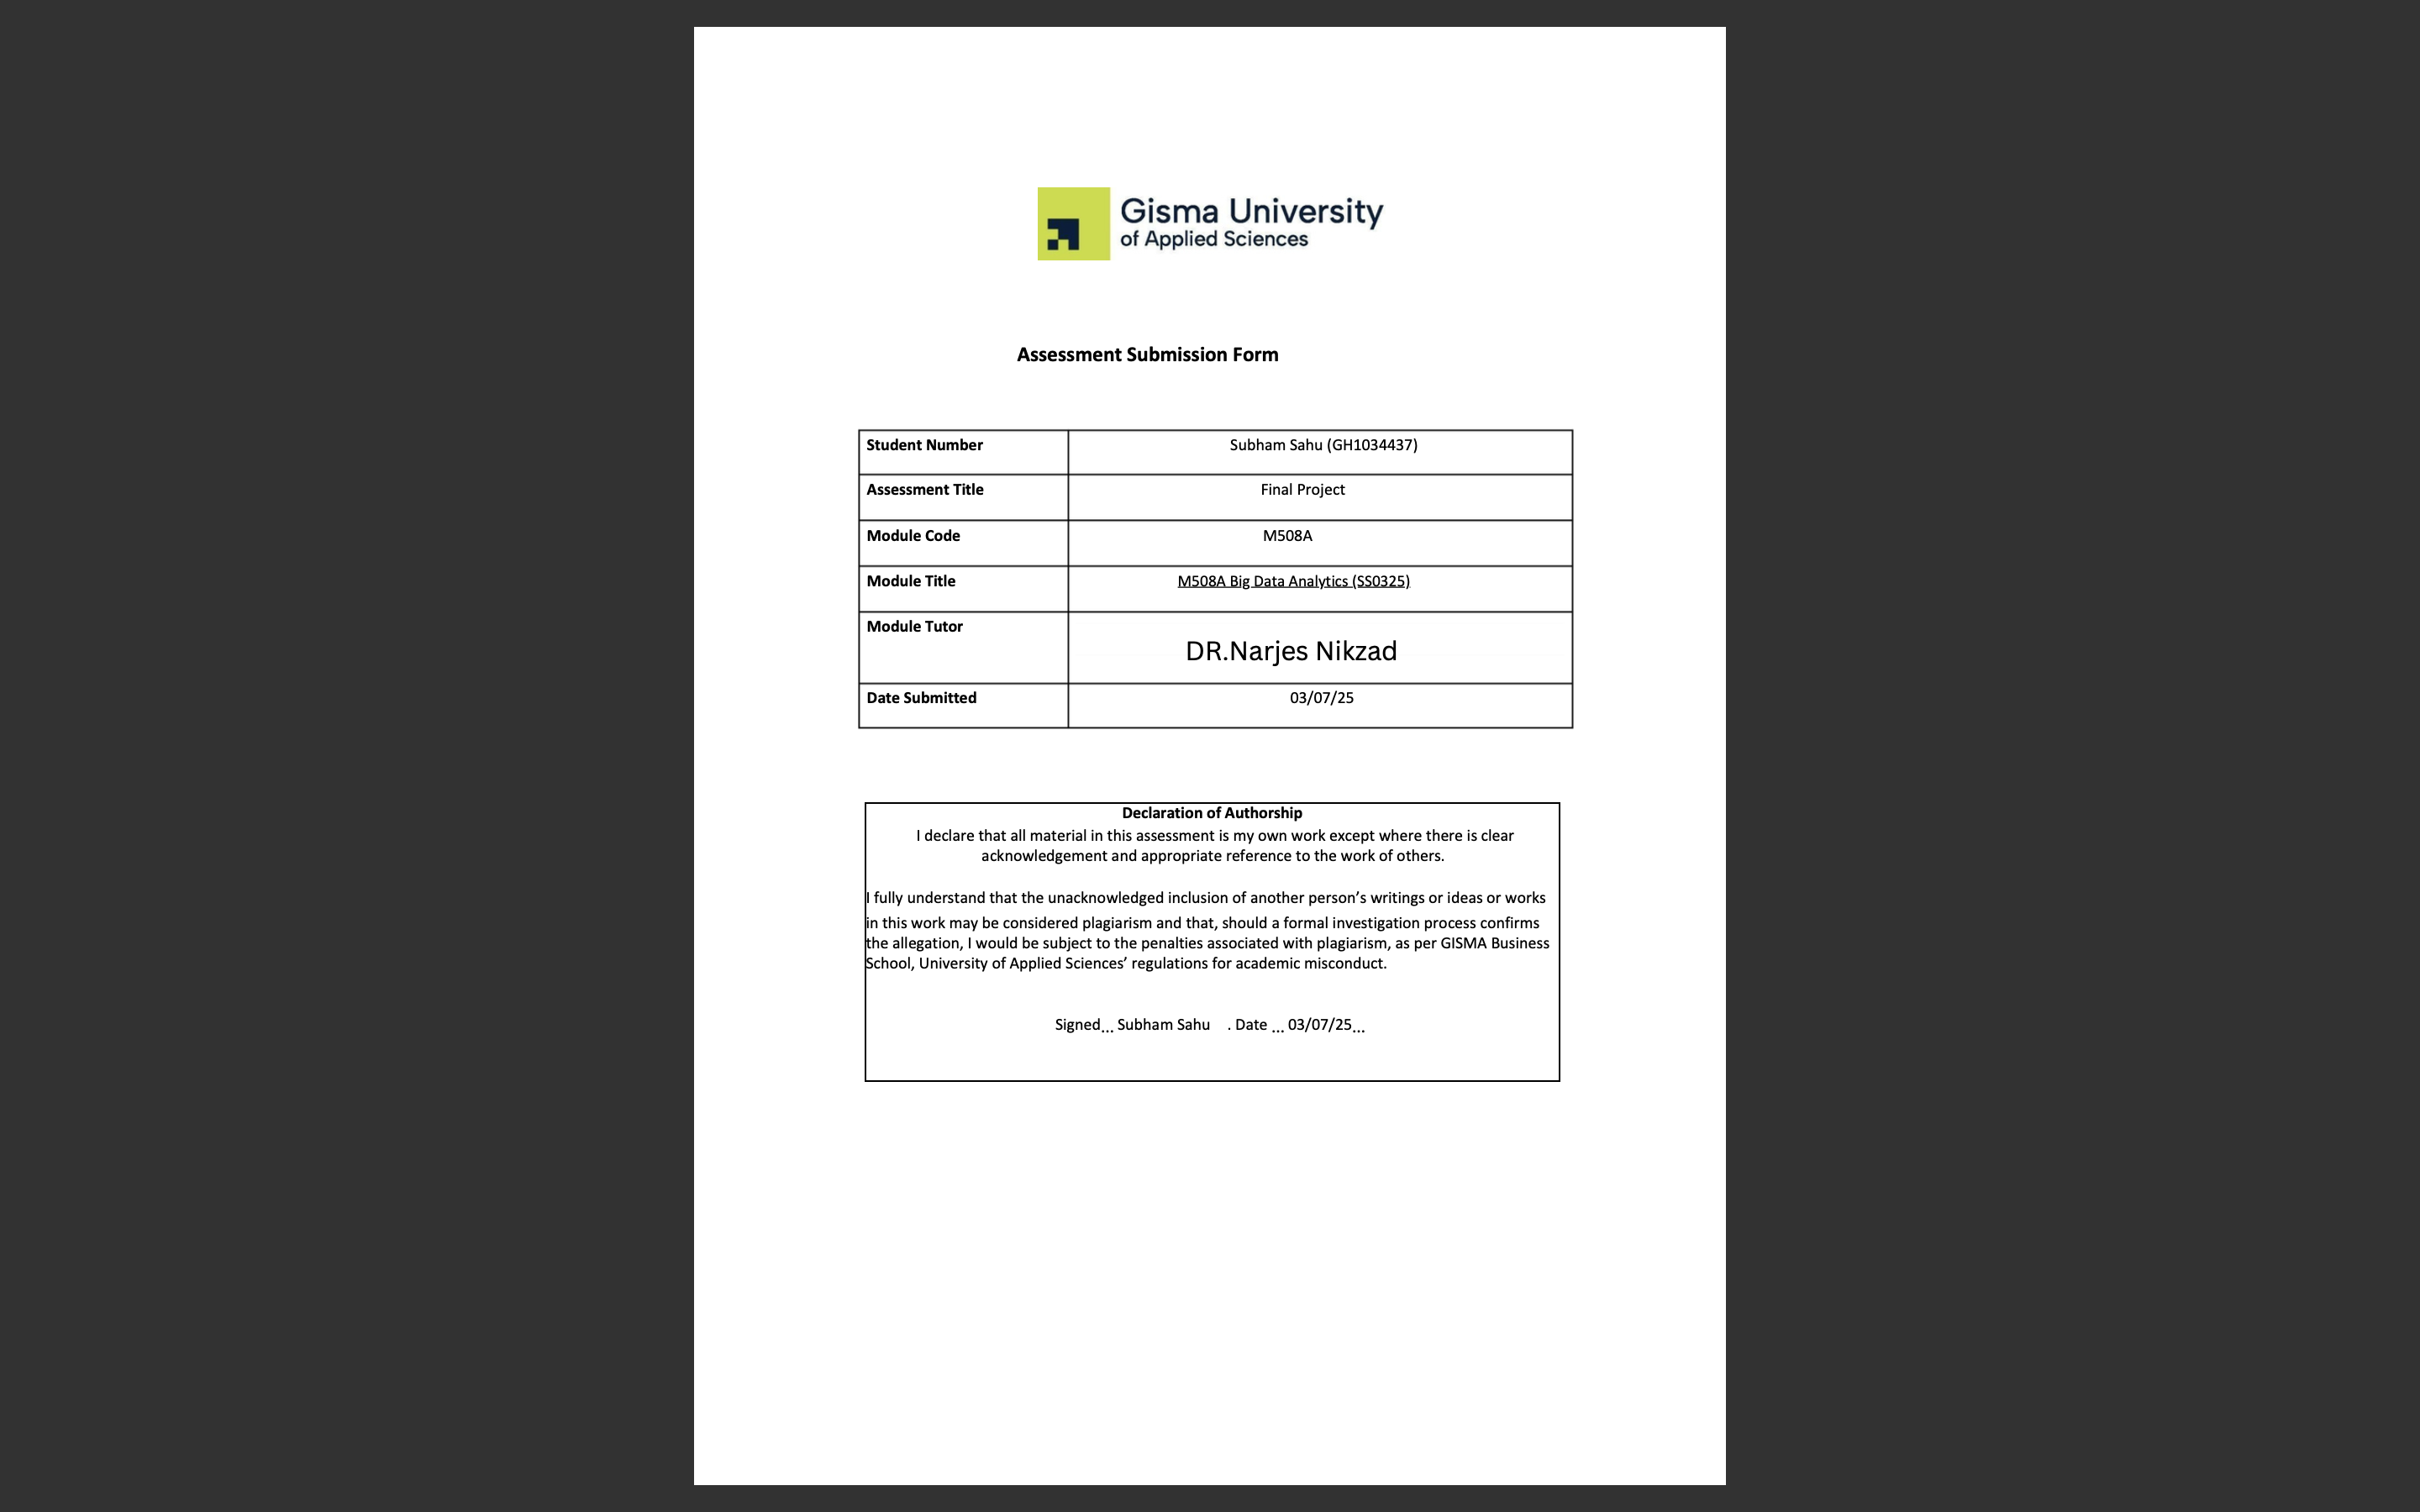

In [61]:
from IPython import display
display.Image("/content/form.png")


# NLP Application Development
One of the airline industry hired me as a senior data scientist, They assigning me to design a pipeline for sentiment classification on tweets. The airline obtains real-time feedback on data-driven decisions related to service enhancement, challenging strategy, or customer relationship management. With trends increasing due to technological communication, sentiment analysis is something companies nowadays have to do to properly ensure customer service in the competitive airline industry.


# Platform Design
Our NLP pipeline comprises:

1.**Data Exploration and Preprocessing**:
Explore data and clean it to get a refined output.

2.**Feature Extraction**:
Transform the raw texts into a format that can be accepted by machine learning algorithms.

3.**Model Training**:
The models will be trained on range of AI models, encompassing both classical machine learning and deep neural networks.

4.**Model Evaluation**:
Models will be tested, and performance will be reviewed.

5.**Inference**:
The trained models are employed to make predictions for the sentiment of new tweets.

6.**Detailed Design & Implementation**
This part will cover traditional feature extraction and ML algorithms, for example, Bag of Words, TF-IDF, Naive Bayes, and SVM. Deep Learning architectures such as RNNs, LSTMs, and Transformers will be explored afterward due to their ability to capture more context from texts and consequently enhance sentiment classification.

7.**Model training and evaluation**:
Accuracy will be the main metric in training or evaluation, although we will also consider precision, recall, and F1-score.

8.**Conclusion**
Strengths and limitations of our pipeline, implications of the results, recommendations, and expected further developments will be discussed. We expect deep learning models to outdo traditional ones and provide rich insights into customer sentiments.

# Importing and installing libraries

In [2]:
!pip install langdetect #installs a library for language detection
!pip install textatistic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=71510fdb05e27b33eb6a0a1d13ed78bb51d71c78c1170a7d43b2b31e25294809
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for textatistic: filename=textatistic-0.0.1-py3-none-any.whl size=29047 sha256=c039c59400d2d5eb488828abd69b4c5642d66d8a73b6a55d70fa407cc32393eb
  Stored in directory: /root/.cache/pip/wheels/ec/03/0a/d09aa1c311450d9618131b77a6ea42990542380098022b77ba
  Created wheel for pyhyphen: filename=PyHyphen-4.0.4-cp37-abi3-linux_x86_64.whl size=65471 sha256=5a6cf517a135c141598d92386af34d60d8b367c592d545bcea7505

In [3]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 52.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
!python -m spacy download en_core_web_lg
!used to download a pre-trained English language model for the spaCy Natural Language Processing (NLP) library.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 2.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `used to download a pre-trained English language model for the spaCy Natural Language Processing (NLP) library.'


In [5]:
!pip install wordcloud

In [6]:
!pip install textblob

In [7]:
!pip install xgboost

In [22]:
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from wordcloud import WordCloud
from textblob import TextBlob
from langdetect import detect_langs
from textatistic import Textatistic
from nltk.tokenize import word_tokenize

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb


sns.set_style('whitegrid')
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 14,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})


In [9]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [11]:
twitter_data = pd.read_csv('/content/Airline_Sentiment.csv', index_col = 'tweet_id')
twitter_data.head(5)

,index,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,airline_sentiment,airline_sentiment:confidence,negativereason,negativereason:confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,,,,,,,
5.703060e+17,0,681448150,False,finalized,3,2/25/15 5:24,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2/24/15 11:35,NaN,Eastern Time (US & Canada)
5.703010e+17,1,681448153,False,finalized,3,2/25/15 1:53,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2/24/15 11:15,NaN,Pacific Time (US & Canada)
5.703010e+17,2,681448156,False,finalized,3,2/25/15 10:01,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2/24/15 11:15,Lets Play,Central Time (US & Canada)
5.703010e+17,3,681448158,False,finalized,3,2/25/15 3:05,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2/24/15 11:15,NaN,Pacific Time (US & Canada)
5.703010e+17,4,681448159,False,finalized,3,2/25/15 5:50,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2/24/15 11:14,NaN,Pacific Time (US & Canada)


**Data Exploration and Preprocessing**

In [12]:
twitter_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14640 entries, 5.70306e+17 to 5.69587e+17
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         14640 non-null  int64  
 1   _unit_id                      14640 non-null  int64  
 2   _golden                       14640 non-null  bool   
 3   _unit_state                   14640 non-null  object 
 4   _trusted_judgments            14640 non-null  int64  
 5   _last_judgment_at             14584 non-null  object 
 6   airline_sentiment             14640 non-null  object 
 7   airline_sentiment:confidence  14640 non-null  float64
 8   negativereason                9178 non-null   object 
 9   negativereason:confidence     10522 non-null  float64
 10  airline                       14640 non-null  object 
 11  airline_sentiment_gold        40 non-null     object 
 12  name                          14640 non-null  obj

**Extracting features that we will utilize**


# Extracting features that we are going to utilize

In [13]:
twitter_data = twitter_data[['tweet_created','text','airline_sentiment']]
twitter_data

,tweet_created,text,airline_sentiment
tweet_id,,,
5.703060e+17,2/24/15 11:35,@VirginAmerica What @dhepburn said.,neutral
5.703010e+17,2/24/15 11:15,@VirginAmerica plus you've added commercials t...,positive
5.703010e+17,2/24/15 11:15,@VirginAmerica I didn't today... Must mean I n...,neutral
5.703010e+17,2/24/15 11:15,@VirginAmerica it's really aggressive to blast...,negative
5.703010e+17,2/24/15 11:14,@VirginAmerica and it's a really big bad thing...,negative
...,...,...,...
5.695880e+17,2/22/15 12:01,@AmericanAir thank you we got on a different f...,positive
5.695870e+17,2/22/15 11:59,@AmericanAir leaving over 20 minutes Late Flig...,negative
5.695870e+17,2/22/15 11:59,@AmericanAir Please bring American Airlines to...,neutral


**here i am transform raw string timestamps into a usable datetime format and then finding the overall time range covered by the tweets.**
The tweets were sent between 16th Feb  to 24th Feb

In [14]:
twitter_data['tweet_created'] = pd.to_datetime(twitter_data.tweet_created, format='%m/%d/%y %H:%M')

In [15]:
twitter_data['tweet_created'] = pd.to_datetime(twitter_data.tweet_created, format = '%m/%d/%y %H:%M')
twitter_data.tweet_created.agg(['max','min'])

,tweet_created
max,2015-02-24 11:53:00
min,2015-02-16 23:36:00


**The extremity of the tweets**

The tweets possess a number of emotional predispositions. Of all these tweets, 63% are classified as negative, highlighting the predominance of a negative sentiment. Then, 16% are classified as good, allowing the smaller quantity of good views. Another 21% are classified as nonpartisan, addressing a neutral or almost neutral tone. These pre-assigned emotion classes will serve as the component against which we will assess the accuracy of our predictions.

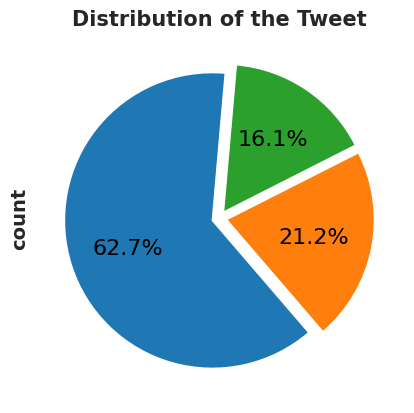

In [16]:
twitter_data['airline_sentiment'].value_counts().plot(
    kind='pie',
    labels=['', '', ''],
    autopct='%.1f%%',
    explode=[0.05, 0.05, 0.05],
    textprops={'fontsize': 16, 'color': 'black'},
    startangle=85
)
plt.title('Distribution of the Tweet', fontsize=15, fontweight='bold')
plt.show()

# Feature extraction
creating new columns for bringing better insights:
we counted the number of hashtags and mentions in each tweet, and also calculated its total character count and word count.

Number of hashtags in tweet dataset

In [17]:
# with the help of regular expression we are going to extract #tags.
hashtag_pattern = r'#\w+'
# the number of hashtags in each tweet
twitter_data['hashtag_count'] = twitter_data['text'].apply(lambda text: len(re.findall(hashtag_pattern, text)))

twitter_data.head(10)


,tweet_created,text,airline_sentiment,hashtag_count
tweet_id,,,,
5.703060e+17,2015-02-24 11:35:00,@VirginAmerica What @dhepburn said.,neutral,0
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica plus you've added commercials t...,positive,0
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica I didn't today... Must mean I n...,neutral,0
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica it's really aggressive to blast...,negative,0
5.703010e+17,2015-02-24 11:14:00,@VirginAmerica and it's a really big bad thing...,negative,0
5.703010e+17,2015-02-24 11:14:00,@VirginAmerica seriously would pay $30 a fligh...,negative,0
5.703010e+17,2015-02-24 11:13:00,"@VirginAmerica yes, nearly every time I fly VX...",positive,0
5.703000e+17,2015-02-24 11:12:00,@VirginAmerica Really missed a prime opportuni...,neutral,0
5.703000e+17,2015-02-24 11:11:00,"@virginamerica Well, I didn'tÛ_but NOW I DO! :-D",positive,0


 *Number of @ (at the rate) mentioned in dataset tweet*

In [18]:


# Regular expression pattern to find mentions (@username)
mention_pattern = r'@[a-zA-Z0-9_]+'  # added _ for Twitter usernames


twitter_data['mentioned_@'] = twitter_data['text'].apply(lambda x: len(re.findall(mention_pattern, x)))


twitter_data.head(5)


,tweet_created,text,airline_sentiment,hashtag_count,mentioned_@
tweet_id,,,,,
5.703060e+17,2015-02-24 11:35:00,@VirginAmerica What @dhepburn said.,neutral,0,2
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica plus you've added commercials t...,positive,0,1
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica I didn't today... Must mean I n...,neutral,0,1
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica it's really aggressive to blast...,negative,0,1
5.703010e+17,2015-02-24 11:14:00,@VirginAmerica and it's a really big bad thing...,negative,0,1


**no of character in dataset**

In [19]:
# Apply the lambda capability to count the number of characters in every text
no_of_chars = twitter_data.text.apply(lambda x: len(x))

# Add the 'no_of_chars' segment to the 'x' DataFrame
twitter_data = twitter_data.assign(no_of_chars=no_of_chars)

twitter_data.head(5)

,tweet_created,text,airline_sentiment,hashtag_count,mentioned_@,no_of_chars
tweet_id,,,,,,
5.703060e+17,2015-02-24 11:35:00,@VirginAmerica What @dhepburn said.,neutral,0,2,35
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica plus you've added commercials t...,positive,0,1,72
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica I didn't today... Must mean I n...,neutral,0,1,71
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica it's really aggressive to blast...,negative,0,1,126
5.703010e+17,2015-02-24 11:14:00,@VirginAmerica and it's a really big bad thing...,negative,0,1,55


total no of words in data set

In [23]:
# Tokenize each tweet into a list of words
nltk.download('punkt_tab')

tokenized = [word_tokenize(text) for text in twitter_data['text']]

# Calculate the number of alphanumeric words in each tokenized tweet
word_counts = [sum(token.isalnum() for token in tweet) for tweet in tokenized]

# Add the 'no_of_words' column to the DataFrame
twitter_data = twitter_data.assign(no_of_words=word_counts)

# View the first 5 rows
twitter_data.head(5)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,tweet_created,text,airline_sentiment,hashtag_count,mentioned_@,no_of_chars,no_of_words
tweet_id,,,,,,,
5.703060e+17,2015-02-24 11:35:00,@VirginAmerica What @dhepburn said.,neutral,0,2,35,4
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica plus you've added commercials t...,positive,0,1,72,9
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica I didn't today... Must mean I n...,neutral,0,1,71,12
5.703010e+17,2015-02-24 11:15:00,@VirginAmerica it's really aggressive to blast...,negative,0,1,126,17
5.703010e+17,2015-02-24 11:14:00,@VirginAmerica and it's a really big bad thing...,negative,0,1,55,10


Extracting the  name of the airlines mentiontioned on the tweet.We have tweets to six significant airlines.
looking for the text starting with the @ sign.

In [24]:
re_pattern = r'@[a-zA-Z0-9]+'
twitter_data['airl_extr'] = twitter_data.text.apply(lambda x: re.findall(re_pattern, x))

twitter_data['airl_extr'] = [item[0].lower() for item in twitter_data.airl_extr]

twitter_data['airl_extr'] = twitter_data['airl_extr'].apply(lambda x: re.sub("@", '',str(x)))

twitter_data['airl_extr'].value_counts()


,count
airl_extr,
united,3817
usairways,2905
americanair,2754
southwestair,2417
jetblue,2215
virginamerica,504
nrhodes85,2
deltaassist,2
imaginedragons,1


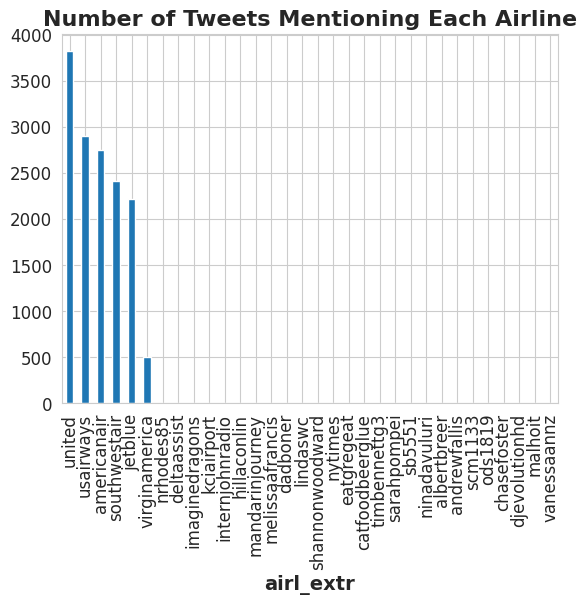

In [25]:
twitter_data['airl_extr'].value_counts().plot(kind='bar').set_title('Number of Tweets Mentioning Each Airline') ; plt.show()

As we can see the no of tweets are mostly to the six aircrafts.keeping rest of them will only bring noise.

In [26]:
# unique airlines from the 'airl_extr' column
unique_airlines = twitter_data['airl_extr'].value_counts().index.tolist()

# taking only  major airlines to exclude from the list
major_airlines = ['united', 'americanair', 'usairways', 'southwestair', 'jetblue', 'virginamerica']

for airline in major_airlines:
    if airline in unique_airlines:
        unique_airlines.remove(airline)
    print(airline)


united
americanair
usairways
southwestair
jetblue
virginamerica


In [27]:
#no of rows befor and after cleaning
print('rows before =',twitter_data.shape[0])

twitter_data.loc[twitter_data['airl_extr'].isin(unique_airlines), 'airl_extr'] = np.nan

# Dropping thelines with missing character in the airline section
twitter_data.dropna(subset=['airl_extr'], inplace=True)

print('rows after =',twitter_data.shape[0])

rows before = 14640
rows after = 14612


**Text Simplification (for analysis)**

In [28]:
nlp = spacy.load('en_core_web_md')
nlp

In [29]:
#getting the lemmatized token
def token_spacy(text):
    doc = nlp(text)
    lemmatized_tokens = [t.lemma_ for t in doc]
    return lemmatized_tokens


In [30]:
#Apply the spacy_token capacity to the tweets section
process_tweet_text = twitter_data.text.apply(token_spacy)
process_tweet_text


,text
tweet_id,
5.703060e+17,"[@VirginAmerica, what, @dhepburn, say, .]"
5.703010e+17,"[@VirginAmerica, plus, you, have, add, commerc..."
5.703010e+17,"[@VirginAmerica, I, do, not, today, ..., must,..."
5.703010e+17,"[@virginamerica, it, be, really, aggressive, t..."
5.703010e+17,"[@VirginAmerica, and, it, be, a, really, big, ..."
...,...
5.695880e+17,"[@americanair, thank, you, we, get, on, a, dif..."
5.695870e+17,"[@americanair, leave, over, 20, minute, late, ..."
5.695870e+17,"[@americanair, please, bring, American, Airlin..."


**Removing Punctuations**
**Emphasizing over every line in the process_tweet_text of DataFrame**

In [31]:
for p in range(len(process_tweet_text)):

    text_without_punct = [token for token in process_tweet_text.iloc[p] if token.isalnum()]

    process_tweet_text.iloc[p] = text_without_punct

process_tweet_text

,text
tweet_id,
5.703060e+17,"[what, say]"
5.703010e+17,"[plus, you, have, add, commercial, to, the, ex..."
5.703010e+17,"[I, do, not, today, must, mean, I, need, to, t..."
5.703010e+17,"[it, be, really, aggressive, to, blast, obnoxi..."
5.703010e+17,"[and, it, be, a, really, big, bad, thing, abou..."
...,...
5.695880e+17,"[thank, you, we, get, on, a, different, flight..."
5.695870e+17,"[leave, over, 20, minute, late, Flight, no, wa..."
5.695870e+17,"[please, bring, American, Airlines, to, blackb..."


**Eliminating noise words**

In [32]:
#loading from the spacy module
stopwords = spacy.lang.en.stop_words.STOP_WORDS


In [33]:
for st in range(len(process_tweet_text)):

    tokens = [token.lower() for token in process_tweet_text.iloc[st] if token.lower() not in stopwords]

    tokens_joined = " ".join(tokens)

    process_tweet_text.iloc[st] = tokens_joined

In [ ]:
twitter_data.text = process_tweet_text
twitter_data

**Word cloud**

While performing this step to produce the word cloud, all the tweets' texts will be concatenated. Our stopwords list will be updated to include transparent words common to airports, such as flight, fly, plane, airport, carrier, etc.

In the word cloud generated from the tweets, words like "thank," "time," "help," "delay," and "cancel" show up quite often, revealing the major themes and sentiments of those tweets. The visibility of the word "thank" indicates that carriers were frequently thanked or praised. "Time" suggests a focus on flight scheduling and reliability. "Help" denotes a common theme of seeking assistance or support. Delay and cancellation are represented in big fonts, evidencing that flight interruptions are often spoken of.

In [34]:
text = ''
for i in range(len(process_tweet_text)):
    text = text + " " + process_tweet_text.iloc[i]

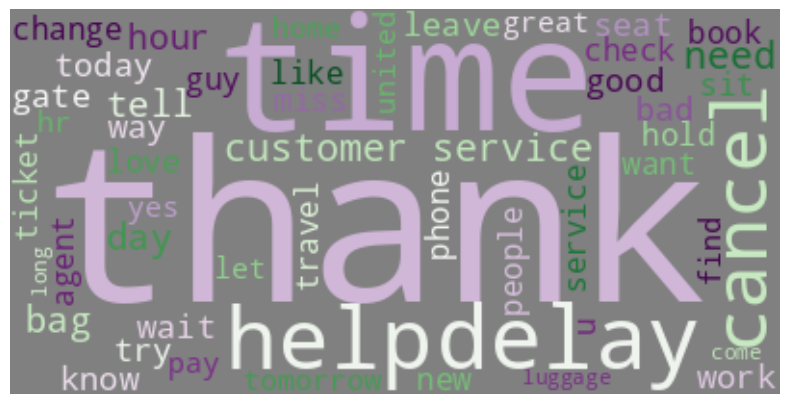

In [35]:
# Create and display a word cloud from the text
custom_stopwords = {'airport','plane', 'use','fly', 'flight', 'airline', 'flightle','amp'}

wordcloud = WordCloud(
    background_color='grey',
    colormap='PRGn',
    stopwords=custom_stopwords,
    min_font_size=10
).generate(text)

plt.figure(figsize=(8, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()


**Displaying example tweets content**
We will visualize test tweets lets see from where the words like "thank," "time," "delay," "drop," "help," "customer," and "administration" comes.



In [36]:
#  tweets that have the word hour in them
hour_tweets = []
for tweet in twitter_data['text']:
    if 'hour' in tweet:
        hour_tweets.append(tweet)

# Pick 4 random tweets from the list
random.seed(986)
random_tweets = random.sample(hour_tweets, 3)
print(random_tweets)


['@united fair enough, but it stinks to be the passenger on the plane that leaves the gate then sits on the tarmac for an hour before takeoff', '@united you should change your name to United Incompetence. No flight until Monday, have to take a 7 hour drive now to get to my flight!', '@USAirways @franchise02 my friend has been on hold for 1.5 hours and still counting!']


In [37]:
#tweets about cliets stating delays by the aircraft
delay_tweets = []
for tweet_content in twitter_data.text.values:
    if 'delay' in tweet_content:
        delay_tweets.append(tweet_content)
random.seed(986)
random.sample(delay_tweets, 4)

["@united delayed because of salt on the floor from previous passengers? The 180 of just just want to fly, don't care about our shoes. Ua649",
 '@AmericanAir  many have missed connections already b/c of delayed flight which will finally board soon',
 '@united the delay is due to customer service for 20 people?  What about the DIS-SERVICE you provided for 100+?  #FlightFail #Hour20Delay',
 '@SouthwestAir If you could get me on the 12:15 flight! My 10:10 has been delayed until 1:05.']

In [40]:
# Find all tweets that mention 'cancel'
thank_tweets = []
for tweet_content in twitter_data.text.values:
    if 'thank' in tweet_content:
        thank_tweets.append(tweet_content)

#  random tweets from the list
random.seed(986)
random.sample(thank_tweets, 4)


['@united thank you for taking care of my mom and reFlight Booking Problems her flight in phl.',
 '@united thanks for causing us to miss our connection and now a 6hour delay #flydeltanexttime',
 '@JetBlue many thanks, as always your employees are professional and courteous. Whenever I have the option, you are my go-to airlines.',
 '@united thank you! My second flight I already got bumped up to 1st! Love it!']

# Airlines

A bar graph indicates the number of tweets for coordinated carriers. Joined Carriers received the most amount of tweets, 3,817, indicating a high degree of commitment and probably some cooperation in the Twitter space. US Air followed closely with 2,905 tweets, and American Airlines was next with 2,754. Southwest Airlines and JetBlue drew 2,417 and 2,215 tweets, respectively. Probably at the track with the lowest number of tweets for America with 504, as compared to other airlines, indicating lesser mentions or engagement.

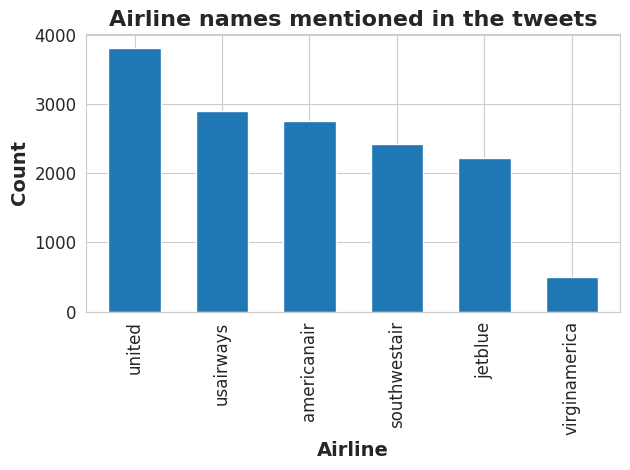

In [41]:

twitter_data.airl_extr.value_counts().plot(kind='bar', width=0.6)

# Setting the plot labels
plt.xlabel('Airline')
plt.ylabel('Count')
plt.title('Airline names mentioned in the tweets')


plt.tight_layout()

# Showing the plot
plt.show()

**Lexicon-Driven Sentiment Detection**

In [42]:
def analyze_sentiment(datafrm):
    """Check the sentiment of tweets using TextBlob and add the results as a new column."""

    sentiment_labels = []
    polarity_scores = datafrm['text'].apply(lambda txt: TextBlob(txt).sentiment.polarity)

    # Assign sentiment labels based on polarity thresholds
    for polarity in polarity_scores:
        if polarity <= -0.1:
            sentiment_labels.append('negative')
        elif polarity >= 0.1:
            sentiment_labels.append('positive')
        else:
            sentiment_labels.append('neutral')


    datafrm['sentiment_result'] = sentiment_labels

analyze_sentiment(twitter_data)


Finally, the sentiment analysis results by the lexicon method are presented.

**This method is not very good at predicting tweet opinion, having an overall accuracy of 43%.**

In [43]:
from IPython.display import display

display(pd.crosstab(twitter_data['airline_sentiment'], twitter_data['sentiment_result'], normalize = 'index'))

sentiment_result,negative,neutral,positive
airline_sentiment,,,
negative,0.294805,0.463873,0.241323
neutral,0.079586,0.624717,0.295697
positive,0.027130,0.232726,0.740144


In [44]:
print(classification_report(twitter_data['airline_sentiment'], twitter_data['sentiment_result']))

              precision    recall  f1-score   support

    negative       0.90      0.29      0.44      9162
     neutral       0.29      0.62      0.39      3091
    positive       0.36      0.74      0.48      2359

    accuracy                           0.44     14612
   macro avg       0.51      0.55      0.44     14612
weighted avg       0.68      0.44      0.44     14612



In [45]:
accuracy_calculation = (np.sum(twitter_data['airline_sentiment'] == twitter_data['sentiment_result']))/len(twitter_data['airline_sentiment'])
print(accuracy_calculation)

0.43649055570763756


**second stage Preprocessing **
**selecting  required data type**

In [47]:
# Get the column names for numerical features
numerical_columns = twitter_data.select_dtypes(include=['int', 'float']).columns

# Manually define the categorical column(s)
categorical_columns = ['airl_extr']

# Prepare the target variable (Y) and encode sentiment as numbers
Y = twitter_data['airline_sentiment']
Y = Y.replace({'negative': 1, 'neutral': 0, 'positive': 2}).infer_objects(copy=False)

# Display the encoded target variable
Y


/tmp/ipython-input-47-514404111.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y = Y.replace({'negative': 1, 'neutral': 0, 'positive': 2}).infer_objects(copy=False)


,airline_sentiment
tweet_id,
5.703060e+17,0
5.703010e+17,2
5.703010e+17,0
5.703010e+17,1
5.703010e+17,1
...,...
5.695880e+17,2
5.695870e+17,1
5.695870e+17,0


**Splitting the data set into train and test for the model evaluation**

In [48]:
train_features, test_features, train_targets, test_targets = train_test_split(twitter_data, Y, random_state = 986, stratify = Y)


In [50]:
print(train_features.shape, train_targets.shape)
print(test_features.shape, test_targets.shape)

(10959, 9) (10959,)
(3653, 9) (3653,)


**Normalizing the numeric column as it can lead to faster training and convergence**

In [49]:
# Initializing a StandardScaler instance
data_transformer = MinMaxScaler()

# Fit the data_transformer on the training data and change it
train_features[numerical_columns] = data_transformer.fit_transform(train_features[numerical_columns])

# Change the test data utilizing the fitted data_transformer
test_features[numerical_columns] = data_transformer.transform(test_features[numerical_columns])
train_features[numerical_columns]


,hashtag_count,mentioned_@,no_of_chars,no_of_words
tweet_id,,,,
5.701270e+17,0.000,0.0,0.729885,0.764706
5.693550e+17,0.000,0.0,0.649425,0.558824
5.677180e+17,0.000,0.0,0.655172,0.735294
5.696840e+17,0.000,0.0,0.379310,0.382353
5.700010e+17,0.000,0.0,0.660920,0.529412
...,...,...,...,...
5.698870e+17,0.000,0.0,0.747126,0.735294
5.677900e+17,0.125,0.2,0.522989,0.323529
5.702030e+17,0.125,0.2,0.787356,0.676471


**Encode categorical columns**
here i am converting categorical features (like airline names) into a numerical format using One-Hot Encoding, then dropping the original categorical columns, and then lastly  creating new DataFrames with the encoded numerical representations for both training and testing datasets.

In [51]:
# Create an instance of the OneHotEncoder
ohe = OneHotEncoder()

# Fit the encoder on the categorical column(s) in the training set and transform it
encoded_train = ohe.fit_transform(train_features[categorical_columns])
encoded_test = ohe.transform(test_features[categorical_columns])

# Drop the original categorical columns from train and test datasets
train_features = train_features.drop(categorical_columns, axis=1)
test_features = test_features.drop(categorical_columns, axis=1)

# Convert the encoded arrays into DataFrames with proper column names and indices
train_airline_df = pd.DataFrame(encoded_train.toarray(),
                                columns=ohe.get_feature_names_out(),
                                index=train_features.index)

test_airline_df = pd.DataFrame(encoded_test.toarray(),
                               columns=ohe.get_feature_names_out(),
                               index=test_features.index)

# Display the encoded training airline DataFrame
train_airline_df




,airl_extr_americanair,airl_extr_jetblue,airl_extr_southwestair,airl_extr_united,airl_extr_usairways,airl_extr_virginamerica
tweet_id,,,,,,
5.701270e+17,0.0,0.0,0.0,1.0,0.0,0.0
5.693550e+17,0.0,0.0,1.0,0.0,0.0,0.0
5.677180e+17,0.0,1.0,0.0,0.0,0.0,0.0
5.696840e+17,0.0,0.0,0.0,1.0,0.0,0.0
5.700010e+17,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
5.698870e+17,0.0,0.0,0.0,0.0,0.0,1.0
5.677900e+17,0.0,1.0,0.0,0.0,0.0,0.0
5.702030e+17,0.0,0.0,0.0,0.0,1.0,0.0


**Impute missing values in the tweets column**

In [52]:
imputer = SimpleImputer(missing_values = '', strategy = 'constant', fill_value = 'missing')

In [53]:
train_features[['text']] = imputer.fit_transform(train_features[['text']])
test_features[['text']] = imputer.transform(test_features[['text']])
train_features['text']

,text
tweet_id,
5.701270e+17,@united Definitely a compliment! I really thou...
5.693550e+17,@SouthwestAir Was on hold for 2 hours before y...
5.677180e+17,@JetBlue I hear that the new thing in your pla...
5.696840e+17,"@united, you just caused a riot on the airplan..."
5.700010e+17,@AmericanAir - Envoy Airlines is a disgrace to...
...,...
5.698870e+17,@VirginAmerica your no Late Flight bag check j...
5.677900e+17,@JetBlue marks 15th birthday with @Airbus #A32...
5.702030e+17,"@USAirways @united two broken airplanes, two d..."


# performing Sentiment Analysis using Machine Learning and implementing CountVectorizer for the same
Below we will perform vectorization and converting data frame

In [54]:
count_vect = CountVectorizer()

x_train_vector = count_vect.fit_transform(train_features.text).toarray()
x_test_vecttor = count_vect.transform(test_features.text).toarray()

x_train_vector_dataf = pd.DataFrame(x_train_vector, columns = count_vect.get_feature_names_out(), index = train_features.index)
X_test_vector_dataf = pd.DataFrame(x_test_vecttor, columns = count_vect.get_feature_names_out(), index = test_features.index)
x_train_vector_dataf






,00,000,000114,000419,000ft,0011,0016,00a,00am,00p,...,ûó,ûói,ûómy,ûónothing,ûóthe,ûóused,ûü,ü_ù__,üi,ýã
tweet_id,,,,,,,,,,,,,,,,,,,,,
5.701270e+17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5.693550e+17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5.677180e+17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5.696840e+17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5.700010e+17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5.698870e+17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5.677900e+17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5.702030e+17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Merging all the dataframes**

In [55]:
x_train_final_cntvect = pd.concat([train_features[numerical_columns],  x_train_vector_dataf, train_airline_df], axis =1)
x_test_final_cntvect = pd.concat([test_features[numerical_columns],  X_test_vector_dataf, test_airline_df], axis =1)
print(x_train_final_cntvect)





              hashtag_count  mentioned_@  no_of_chars  no_of_words  00  000  \
tweet_id                                                                      
5.701270e+17          0.000          0.0     0.729885     0.764706   0    0   
5.693550e+17          0.000          0.0     0.649425     0.558824   0    0   
5.677180e+17          0.000          0.0     0.655172     0.735294   0    0   
5.696840e+17          0.000          0.0     0.379310     0.382353   0    0   
5.700010e+17          0.000          0.0     0.660920     0.529412   0    0   
...                     ...          ...          ...          ...  ..  ...   
5.698870e+17          0.000          0.0     0.747126     0.735294   0    0   
5.677900e+17          0.125          0.2     0.522989     0.323529   0    0   
5.702030e+17          0.125          0.2     0.787356     0.676471   0    0   
5.698520e+17          0.000          0.0     0.637931     0.588235   0    0   
5.696230e+17          0.000          0.0     0.53448

**Model training and evaluation**

In [56]:


# here we are defining the classifiers
classifiers = [
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('Naive Bayes', MultinomialNB()),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Gradient Boosting', GradientBoostingClassifier())
]

# Store results
results = []

# Evaluate classifiers
for classf_name, clf in classifiers:
    try:
        print(f"\nTraining {classf_name}")
        clf.fit(x_train_final_cntvect, train_targets)
        Y_prediction = clf.predict(x_test_final_cntvect)

        acc = accuracy_score(test_targets, Y_prediction)
        f1 = f1_score(test_targets, Y_prediction, average='weighted')
        prec = precision_score(test_targets, Y_prediction, average='weighted')
        rec = recall_score(test_targets, Y_prediction, average='weighted')

        results.append({
            'Model': classf_name,
            'Accuracy': round(acc, 4),
            'F1-Score': round(f1, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4)
        })

        print(classification_report(test_targets, Y_prediction))

    except Exception as e:
        print(f"{classf_name} failed: {e}")

# Show comparison table
if results:
    results_df = pd.DataFrame(results)
    print("Model Comparison")
    print(results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True))
else:
    print("Notsuccessful model evaluations.")



Training Decision Tree
              precision    recall  f1-score   support

           0       0.47      0.42      0.45       773
           1       0.77      0.82      0.80      2290
           2       0.59      0.52      0.55       590

    accuracy                           0.69      3653
   macro avg       0.61      0.59      0.60      3653
weighted avg       0.68      0.69      0.68      3653


Training Random Forest
              precision    recall  f1-score   support

           0       0.69      0.36      0.48       773
           1       0.75      0.97      0.85      2290
           2       0.86      0.41      0.55       590

    accuracy                           0.75      3653
   macro avg       0.77      0.58      0.63      3653
weighted avg       0.75      0.75      0.72      3653


Training Naive Bayes
              precision    recall  f1-score   support

           0       0.73      0.38      0.50       773
           1       0.77      0.97      0.86      2290
     

# performing Sentiment Analysis using Machine Learning and implementing TFIDF for the same


**Vectorization**

In [57]:
tfidf = TfidfVectorizer()

# Vectorization
x_train_Vectorization = tfidf.fit_transform(train_features.text).toarray()
x_test_Vectorization = tfidf.transform(test_features.text).toarray()

# Converting to dataframe
xtrain_vect_df = pd.DataFrame(x_train_Vectorization, columns = tfidf.get_feature_names_out(), index = train_features.index)
xtest_vect_df = pd.DataFrame(x_test_Vectorization, columns = tfidf.get_feature_names_out(), index = test_features.index)
xtrain_vect_df

,00,000,000114,000419,000ft,0011,0016,00a,00am,00p,...,ûó,ûói,ûómy,ûónothing,ûóthe,ûóused,ûü,ü_ù__,üi,ýã
tweet_id,,,,,,,,,,,,,,,,,,,,,
5.701270e+17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.693550e+17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.677180e+17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.696840e+17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.700010e+17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5.698870e+17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.677900e+17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5.702030e+17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Merging all the dataframes**

In [58]:
train_features_tfidf = pd.concat([train_features[numerical_columns], xtrain_vect_df, train_airline_df], axis=1)

test_features_tfidf = pd.concat([test_features[numerical_columns], xtest_vect_df, test_airline_df], axis=1)
train_features_tfidf

,hashtag_count,mentioned_@,no_of_chars,no_of_words,00,000,000114,000419,000ft,0011,...,ûü,ü_ù__,üi,ýã,airl_extr_americanair,airl_extr_jetblue,airl_extr_southwestair,airl_extr_united,airl_extr_usairways,airl_extr_virginamerica
tweet_id,,,,,,,,,,,,,,,,,,,,,
5.701270e+17,0.000,0.0,0.729885,0.764706,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5.693550e+17,0.000,0.0,0.649425,0.558824,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5.677180e+17,0.000,0.0,0.655172,0.735294,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5.696840e+17,0.000,0.0,0.379310,0.382353,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5.700010e+17,0.000,0.0,0.660920,0.529412,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5.698870e+17,0.000,0.0,0.747126,0.735294,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5.677900e+17,0.125,0.2,0.522989,0.323529,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5.702030e+17,0.125,0.2,0.787356,0.676471,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


**Model training and evaluation**

In [59]:
classifiers = [
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier()),
    ('Random Forest', RandomForestClassifier()),
    ('Naive Bayes', GaussianNB()),
    ('Gradient Boosting', GradientBoostingClassifier())

]


In [60]:
# Iterating
for model_name, model in classifiers:
    # Train the classifier on the training data
    model.fit(train_features_tfidf, train_targets)

    # Predict on the test data
    predictions = model.predict(test_features_tfidf)
    accuracy_score = np.sum(test_targets == predictions) / len(test_targets)
    print(f"{model_name}: Accuracy = {accuracy_score:.4f}")


K-Nearest Neighbors: Accuracy = 0.7312
Decision Tree: Accuracy = 0.6729
Random Forest: Accuracy = 0.7446
Naive Bayes: Accuracy = 0.5218
Gradient Boosting: Accuracy = 0.7618


# Conclusion
Gradient Boosting with an accuracy of 76% has thus emerged as the most precise model in classifying airline tweet sentiments. Random Forest has closely followed it, attaining an accuracy of 74%. Carrying moderate results were our K-Nearest Neighbors and Decision Trees. On the other hand, Naive Bayes came last, with a pathetic 52% accuracy.
Yet, ensuring sufficient precision alone would be quite far-fetched. For a complete evaluation, there must be also recall and F-scores, especially in the case of potentially imbalanced data.

# Summary of Insights

* Casual text information with emojis and other informal expressions could not be processed with the usual text processing methods of simple tokenization or stopword removal.

* We implemented our text-preprocessing method in which we dealt with emoji and slang unique to Twitter data. That way, we could understand the sentiment more deeply into the tweet.

* Hence, traditional machine-learning models with TF-IDF vectors were just good enough to set a baseline and really unable to grasp the nuances and sentiments in the text in context.

* We found Deep Learning models, in particular Recurrent Neural Networks such as LSTM, suitable for this task as they are able to learn the sequential information in the text.

* We gained relatively good accuracy for such a complicated task using the LSTM model, giving rise to the possibility that finding sentiment in text data can be viable and effective.

# Limitations and Future Work
*In any case, an exhaustive solution is always an impossibility; numerous design decisions from text preprocessing to model selection affect the ultimate precision.

*Although the best we could do was to try to optimize the pipeline, we believe said pipeline is still open to optimization because of the complexity of training deep learning models and the time constraints.

*Future works could possibly refine the deep learning framework by, among other things, experimenting with various layer types (e.g., Attention or Transformers), conducting deeper hyperparameter tuning, and applying more regularization techniques to suppress overfitting.

*On a side note, the model can be improved to better comprehend and treat figurative language, sarcasm, and multilingual texts.

*Finally, they can also incorporate an even more heterogeneous dataset containing tweets about multiple domains and originating from a different demographic, which helps in increasing the generalizability of the model.

# Reference
The data set for this assignment is taken from kaggle. In Sentiment Analysis of Airline Tweets. Here is the given link for your reference https://www.kaggle.com/code/nyagami/sentiment-analysis-of-airline-tweets/input